# Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

# models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Define the Problem

In [4]:
# Load the dataset
data = pd.read_sas("LLCP2024.XPT ", format="xport", encoding="latin1")

#View dataset shape and columns
print(f"Dataset shape: {data.shape}")
print(list(data.columns))

# first 10 rows of the dataset
display(data.head(10))

Dataset shape: (457670, 301)
['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'V

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,02282024,02,28,2024,1100.0,2024000001,2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,02212024,02,21,2024,1100.0,2024000002,2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,02212024,02,21,2024,1100.0,2024000003,2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,02282024,02,28,2024,1100.0,2024000004,2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,02212024,02,21,2024,1100.0,2024000005,2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
5,1.0,2.0,02212024,02,21,2024,1100.0,2024000006,2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
6,1.0,2.0,02262024,02,26,2024,1100.0,2024000007,2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,1.0,2.0
7,1.0,2.0,02212024,02,21,2024,1100.0,2024000008,2.024000e+09,1.0,...,2.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,1.0,2.0
8,1.0,2.0,02202024,02,20,2024,1100.0,2024000009,2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,1.0
9,1.0,2.0,02262024,02,26,2024,1100.0,2024000010,2.024000e+09,1.0,...,1.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0


In [7]:
# Selecting relavant features for diabetes prediction 
features = [
    '_AGE80','_SEX','EDUCA','INCOME3','EXERANY2',
    '_SMOKER3','ALCDAY4','_BMI5','EMPLOY1',
    'GENHLTH','PHYSHLTH','CVDINFR4','CVDCRHD4','SDHFOOD1'
]

target = 'DIABETE4'


# create working dataset with only needed columns
data_model = data[features + [target]].copy()


# converting DIABETE4 into binary (classification problem)
# 1 = diabetes, 4 = pre-diabetes (also treating as positive)
# 2 = no diabetes
# others = unclear, remove them
def convert_diabetes(x):
    if x in (1, 4):   
        return 1
    elif x == 2:      
        return 0
    else:
        return np.nan

data_model['DIABETES_BIN'] = data_model[target].apply(convert_diabetes)

# dropping rows where target is missing
data_model = data_model.dropna(subset=['DIABETES_BIN'])

# converting to integer type
data_model['DIABETES_BIN'] = data_model['DIABETES_BIN'].astype(int)

# check class distribution (important for imbalance)
print("\nTarget distribution:")
print(data_model['DIABETES_BIN'].value_counts())



Target distribution:
DIABETES_BIN
1    77116
0     3395
Name: count, dtype: int64


# 2. Explore the Data

In [44]:
#Data Structure and Summary Statistics
# basic info about the dataset
print("\nDataset Info:")
data_model.info()

# summary statistics
print("\nSummary statistics:")
display(data_model.describe())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 80511 entries, 5 to 457669
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _AGE80        80511 non-null  float64
 1   _SEX          80511 non-null  float64
 2   EDUCA         80170 non-null  float64
 3   INCOME3       65324 non-null  float64
 4   EXERANY2      80194 non-null  float64
 5   _SMOKER3      75184 non-null  float64
 6   ALCDAY4       73412 non-null  float64
 7   _BMI5         73470 non-null  float64
 8   EMPLOY1       79305 non-null  float64
 9   GENHLTH       80222 non-null  float64
 10  PHYSHLTH      77621 non-null  float64
 11  CVDINFR4      79634 non-null  float64
 12  CVDCRHD4      78976 non-null  float64
 13  SDHFOOD1      37007 non-null  float64
 14  DIABETE4      80511 non-null  float64
 15  DIABETES_BIN  80511 non-null  int64  
dtypes: float64(15), int64(1)
memory usage: 10.4 MB

Summary statistics:


,_AGE80,_SEX,EDUCA,INCOME3,EXERANY2,_SMOKER3,ALCDAY4,_BMI5,EMPLOY1,GENHLTH,PHYSHLTH,CVDINFR4,CVDCRHD4,SDHFOOD1,DIABETE4,DIABETES_BIN
count,80511.000000,80511.000000,80170.000000,65324.000000,80194.000000,75184.000000,73412.000000,73470.000000,79305.000000,80222.000000,77621.000000,79634.000000,78976.000000,37007.000000,80511.000000,80511.000000
mean,63.347021,1.528922,4.824935,6.261680,1.361860,3.337253,2.798364,31.358651,4.988034,3.234848,7.653947,1.868586,1.860084,4.457427,1.463489,0.957832
std,13.589444,0.499166,1.072913,2.434346,0.480542,0.899471,6.492059,7.339842,2.815772,1.003934,11.086542,0.337854,0.346902,1.031403,1.044664,0.200974
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,12.110000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,55.000000,1.000000,4.000000,5.000000,1.000000,3.000000,0.000000,26.500000,1.000000,3.000000,0.000000,2.000000,2.000000,4.000000,1.000000,1.000000
50%,66.000000,2.000000,5.000000,6.000000,1.000000,4.000000,0.000000,30.170000,7.000000,3.000000,1.000000,2.000000,2.000000,5.000000,1.000000,1.000000
75%,74.000000,2.000000,6.000000,8.000000,2.000000,4.000000,2.000000,34.970000,7.000000,4.000000,14.000000,2.000000,2.000000,5.000000,1.000000,1.000000
max,80.000000,2.000000,6.000000,11.000000,2.000000,4.000000,30.331000,99.840000,8.000000,5.000000,30.000000,2.000000,2.000000,5.000000,4.000000,1.000000


### Handle BRFSS coded values for exploration

In [8]:
# BRFSS special codes by variable
# 7/77/777 = Don't know, 9/99/999 = Refused, 88/888 = None (legitimate zero)
SPECIAL_CODES = {
    '_SEX'    : [7, 9],
    'EDUCA'   : [9],
    'INCOME3' : [77, 99],
    'EXERANY2': [7, 9],
    '_SMOKER3': [9],
    'ALCDAY4' : [777, 999],  
    'EMPLOY1' : [9],
    'GENHLTH' : [7, 9],
    'PHYSHLTH': [77, 99],     
    'CVDINFR4': [7, 9],
    'CVDCRHD4': [7, 9],
    'SDHFOOD1': [7, 9],
    '_AGE80'  : [],            
    '_BMI5'   : [],            
}

#Replace special codes with NaN
for col in features:
    codes = SPECIAL_CODES.get(col, [])
    data_model[col] = data_model[col].replace(codes, np.nan)


In [9]:
# PHYSHLTH: 88 = "None / 0 days" -> real zero
if 'PHYSHLTH' in data_model.columns:
    data_model['PHYSHLTH'] = data_model['PHYSHLTH'].replace(88, 0)

# ALCDAY4: 888 = "no drinks" → real zero
# Values 101–130 = days/week, 201–230 = days/month 
def recode_alcday(val):
    if pd.isna(val):
        return np.nan
    v = int(val)
    if v == 888:                 
        return 0
    elif 101 <= v <= 130:        
        return (v - 100) * 4.333
    elif 201 <= v <= 230:        
        return v - 200
    else:
        return np.nan            

if 'ALCDAY4' in data_model.columns:
    data_model['ALCDAY4'] = data_model['ALCDAY4'].apply(recode_alcday)

if '_BMI5' in data_model.columns:
    data_model['_BMI5'] = data_model['_BMI5'] / 100.0

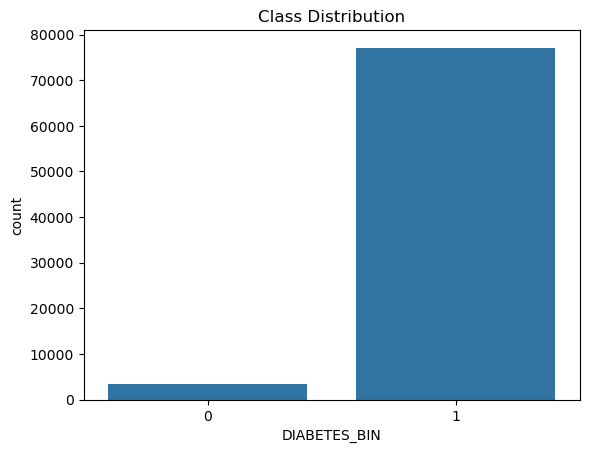

In [10]:
# check class imbalance
sns.countplot(x='DIABETES_BIN', data=data_model)
plt.title("Class Distribution")
plt.show()



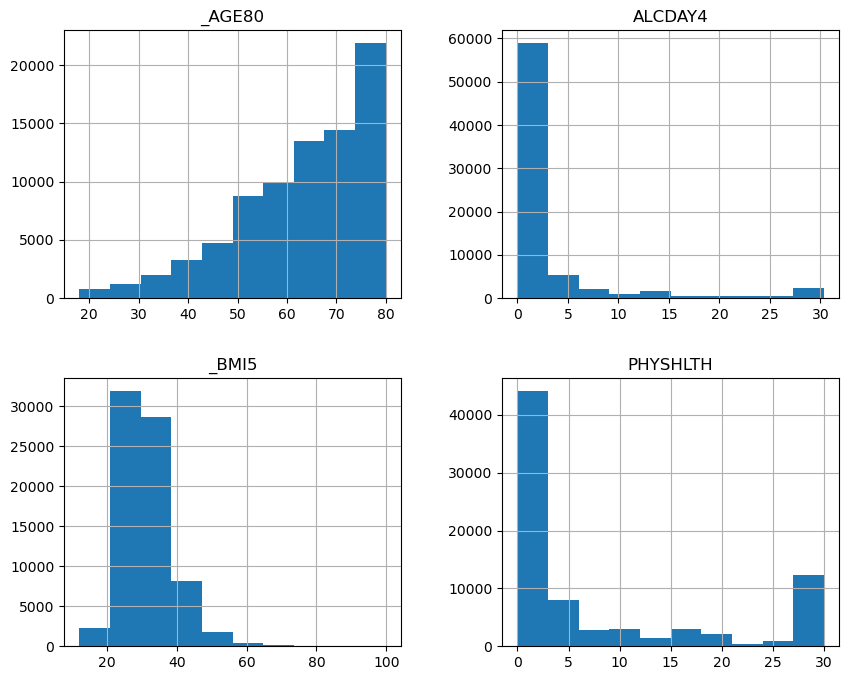

In [11]:
# numeric variables
numeric_cols = ['_AGE80','ALCDAY4','_BMI5','PHYSHLTH']

data_model[numeric_cols].hist(figsize=(10,8))
plt.show()

# 3. PREPROCESSING

In [12]:
x = data_model[features]
y = data_model['DIABETES_BIN']

# we split before handling missing values to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2,
    random_state=42, 
    stratify=y)


# imputing missing values using median strategy 
imputer = SimpleImputer(strategy='median')

 #learning median from train only
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=features)

# applies train medians to test — no peeking
X_test = pd.DataFrame(imputer.transform(X_test),columns=features)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"NaNs remaining — train: {X_train.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")

Train: (64408, 14), Test: (16103, 14)
NaNs remaining — train: 0, test: 0


In [13]:
#Scale numeric features - this is important for models like logistic regression and XGBoost,
# and generally good practice for numeric features. 
# We fit the scaler on the training data only to avoid data leakage, 
# then apply the same transformation to the test set.
scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=features) 
X_test = pd.DataFrame(scaler.transform(X_test), columns=features)

In [14]:
print("Before SMOTE:", Counter(y_train))

# balance classes using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_res))

Before SMOTE: Counter({1: 61692, 0: 2716})
After SMOTE: Counter({0: 61692, 1: 61692})


# 4. Baseline model

In [41]:
# creating a simple baseline model that always predicts the majority class
# this helps us understand the minimum performance to beat
dummy = DummyClassifier(strategy='most_frequent', random_state=42)

# training baseline model on resampled training data
dummy.fit(X_train_res, y_train_res)

# make predictions on test data (never use SMOTE data for testing)
y_pred_dummy = dummy.predict(X_test)

# print baseline performance
print("BASELINE MODEL (Most Frequent Class)")
print("="*45)
print(classification_report(
    y_test, y_pred_dummy,
    target_names=['No Diabetes', 'Diabetes'],
    zero_division=0
))



BASELINE MODEL (Most Frequent Class)
              precision    recall  f1-score   support

 No Diabetes       0.04      1.00      0.08       679
    Diabetes       0.00      0.00      0.00     15424

    accuracy                           0.04     16103
   macro avg       0.02      0.50      0.04     16103
weighted avg       0.00      0.04      0.00     16103



# 5. Model Training

### we use three models:
### Logistic Regression -> simple & interpretable
### Random Forest -> handles nonlinear patterns well
### XGBoost -> usually best performance on structured data


### Logistic Regression

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(
    C=0.1, 
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
    )

#Training Model
log_reg.fit(X_train_res, y_train_res)

#Predicting on test set
y_pred_log_reg = log_reg.predict(X_test)

# Tuning — search over regularisation strength
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='lbfgs',
                       class_weight='balanced', random_state=42),
    {'C': [0.01, 0.1, 1, 10]},
    cv=5, scoring='roc_auc', n_jobs=-1
)

#fit tuning
lr_grid.fit(X_train_res, y_train_res)

#Getting best model
print(f"Logistic Regression best C : {lr_grid.best_params_['C']}")
log_reg_tuned = lr_grid.best_estimator_

#final predictions with tuned model
y_pred_log_reg_tuned = log_reg_tuned.predict(X_test)


Logistic Regression best C : 10


### Random Forest

In [44]:
# creating model with reasonable parameters
random_fr = RandomForestClassifier(
    n_estimators=200,       
    max_depth=10,           
    min_samples_leaf=20,    
    class_weight='balanced',
    random_state=42
)

random_fr.fit(X_train_res, y_train_res)

# predictions
y_pred_random_fr = random_fr.predict(X_test)

# tune Random Forest
random_f_grid = GridSearchCV(
    RandomForestClassifier(
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ),
    {'n_estimators': [100, 200],
     'max_depth': [8, 10, 12]},
    cv=5,
    scoring='roc_auc'
)

random_f_grid.fit(X_train_res, y_train_res)

print("Best RF params:", random_f_grid.best_params_)
random_fr_tuned = random_f_grid.best_estimator_

y_pred_random_fr_tuned = random_fr_tuned.predict(X_test)


Best RF params: {'max_depth': 12, 'n_estimators': 200}


### XGBoost

In [45]:
#computing imbalance ratio (helps model focus on minority class)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

# create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42
)

# train model
xgb_model.fit(X_train_res, y_train_res)

# tune model
xgb_grid = GridSearchCV(
    XGBClassifier(
        n_estimators=300,
        eval_metric='logloss',
        random_state=42
    ),
    {'max_depth': [4, 5, 6],
     'learning_rate': [0.01, 0.05, 0.1]},
    cv=5,
    scoring='roc_auc'
)

xgb_grid.fit(X_train_res, y_train_res)

print("Best XGB params:", xgb_grid.best_params_)
xgb_tuned = xgb_grid.best_estimator_

y_pred_xgb_tuned = xgb_tuned.predict(X_test)


Best XGB params: {'learning_rate': 0.1, 'max_depth': 6}


# 6. Evaluation

In [39]:

# function to evaluate model performance in one place
def evaluate(name, y_true, y_pred, y_prob=None):
    
    # print model name clearly
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    # basic classification metrics
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))

    # ROC-AUC (only if probabilities are available)
    if y_prob is not None:
        print("ROC-AUC:", roc_auc_score(y_true, y_prob))

    # detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # plot confusion matrix to see errors clearly
    fig, ax = plt.subplots(figsize=(4,3))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['No Diabetes', 'Diabetes']
    ).plot(ax=ax, colorbar=False)

    ax.set_title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()


Logistic Regression (Tuned)
Accuracy: 0.8055641805874681
Precision: 0.9925474797660069
Recall: 0.8030342323651453
F1 Score: 0.8877898433860159
ROC-AUC: 0.9119930628548206

Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.86      0.27       679
           1       0.99      0.80      0.89     15424

    accuracy                           0.81     16103
   macro avg       0.58      0.83      0.58     16103
weighted avg       0.96      0.81      0.86     16103



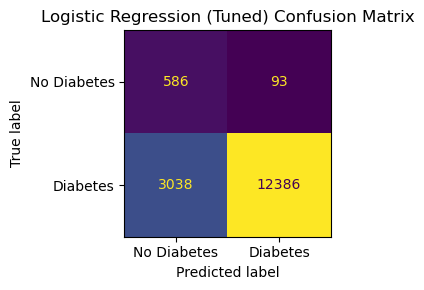


Random Forest (Tuned)
Accuracy: 0.8979693224864932
Precision: 0.9840533895328416
Recall: 0.908195020746888
F1 Score: 0.9446036616204188
ROC-AUC: 0.9042174676421879

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.67      0.35       679
           1       0.98      0.91      0.94     15424

    accuracy                           0.90     16103
   macro avg       0.61      0.79      0.65     16103
weighted avg       0.95      0.90      0.92     16103



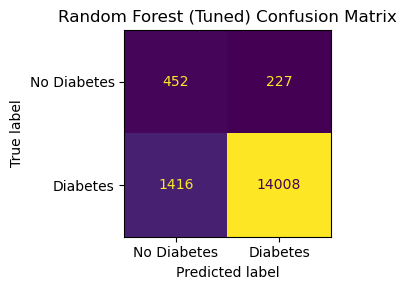


XGBoost (Tuned)
Accuracy: 0.953176426752779
Precision: 0.9712798766383963
Recall: 0.9800959543568465
F1 Score: 0.9756680005163288
ROC-AUC: 0.8983127016634177

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.34      0.38       679
           1       0.97      0.98      0.98     15424

    accuracy                           0.95     16103
   macro avg       0.70      0.66      0.68     16103
weighted avg       0.95      0.95      0.95     16103



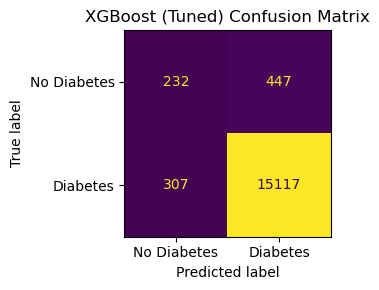

In [48]:
# evaluate all models
evaluate(
    "Logistic Regression (Tuned)",
    y_test,
    y_pred_log_reg_tuned,
    log_reg_tuned.predict_proba(X_test)[:,1]
)

evaluate(
    "Random Forest (Tuned)",
    y_test,
    y_pred_random_fr_tuned,
    random_fr_tuned.predict_proba(X_test)[:,1]
)

evaluate(
    "XGBoost (Tuned)",
    y_test,
    y_pred_xgb_tuned,
    xgb_tuned.predict_proba(X_test)[:,1]
)


## ROC Curves

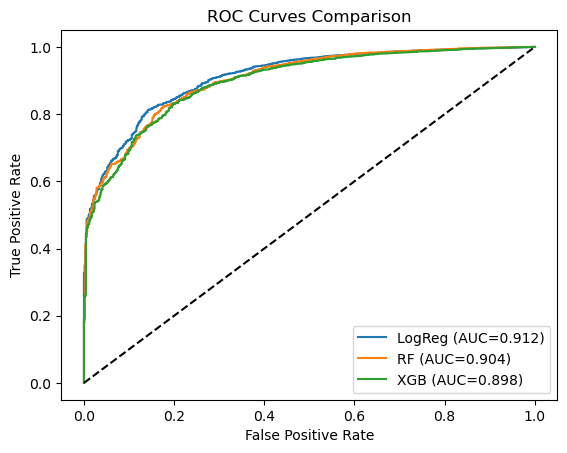

In [49]:

# store probabilities for all models
models = {
    "LogReg": log_reg_tuned,
    "RF": random_fr_tuned,
    "XGB": xgb_tuned
}

# plot ROC for each model
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# diagonal baseline line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()
